# 06. Eksperimen Transfer Learning (DenseNet121) - PneumoVision_AI

## 1. Pendahuluan & Latar Belakang Eksperimen

Selamat datang di tahap keenam pengembangan **PneumoVision_AI**! 🫁

### Apa itu Transfer Learning?
**Transfer Learning** adalah teknik deep learning di mana arsitektur model yang telah dilatih secara ekstensif pada dataset citra berskala masif (ImageNet dengan 1,2+ juta citra) digunakan kembali sebagai fondasi ekstraksi fitur untuk menyelesaikan tugas klasifikasi pada domain spesifik, yaitu citra rontgen dada (*Chest X-Ray*).

Alih-alih menginisialisasi jutaan parameter konvolusi secara acak, model memanfaatkan filter visual hierarkis yang sudah terbentuk matang—mulai dari deteksi batas anatomi tulang iga, diafragma, hingga tekstur infiltrat halus pada parenkim paru—kemudian menyesuaikan bobotnya (*fine-tuning*) untuk membedakan kondisi `NORMAL` dan `PNEUMONIA`.

### Penjelasan Singkat Arsitektur DenseNet121:
**DenseNet (Densely Connected Convolutional Networks)** yang diperkenalkan oleh Huang et al. (2017) mengusung filosofi konektivitas radikal: setiap layer menerima *feature maps* dari **semua layer sebelumnya** dan meneruskan *feature maps*-nya sendiri ke **semua layer berikutnya** melalui operasi konkatenasi (*channel-wise concatenation*).

Keunggulan utama DenseNet121:
1. **Maksimalisasi Feature Reuse**: Fitur visual level rendah (sudut, garis) dan level tinggi (pola opasitas) dapat diakses secara simultan di seluruh kedalaman jaringan tanpa perlu dipelajari ulang.
2. **Mitigasi Vanishing Gradient & Penguatan Propagasi Sinyal**: Setiap layer memiliki akses langsung ke gradien fungsi loss melalui koneksi pendek (*dense connections*).
3. **Efisiensi Parameter Tinggi**: DenseNet121 hanya memiliki **~6,96 juta parameter**, lebih ringkas daripada ResNet18 (~11,18M parameter), karena tiap konvolusi hanya menambahkan sejumlah kecil kanal baru (*growth rate* $k=32$).

### Mengapa DenseNet121 Diuji Setelah ResNet18 dan EfficientNet-B0?
- Dalam literatur computer vision medis global, **DenseNet121 adalah standar *de-facto*** yang menjadi tulang punggung model-model terkemuka seperti **CheXNet** (Rajpurkar et al., Stanford 2017) dan model-model kompetisi **CheXpert** serta **NIH ChestX-ray14**.
- Karakteristik opasitas pneumonia yang sering kali berupa bercak samar, konsolidasi fokal, atau infiltrat interstitial sangat cocok dengan sifat *feature reuse* rapat dari DenseNet.
- Eksperimen ini bertujuan menguji secara objektif:
  > *"Apakah DenseNet121 mampu mengungguli ResNet18 dan EfficientNet-B0 dalam hal F1-Score, Akurasi, dan keseimbangan Sensitivity-Specificity pada data uji rontgen dada yang terkunci?"*

> ⚠️ **Disclaimer Medis**:  
> *PneumoVision_AI adalah prototipe penapisan (*screening/research prototype*) untuk tujuan riset dan edukasi, serta **BUKAN** merupakan alat diagnosis medis klinis (*clinical diagnostic tool*). Diagnosis medis klinis resmi tetap menjadi wewenang dokter spesialis radiologi.*

## 2. Setup Lingkungan & Data Preparation

Kita mengimpor seluruh pustaka yang diperlukan, mengunci random seed (42) agar eksperimen bersifat *reproducible*, dan memuat data loader dari pipeline preprocessing yang identik dengan notebook 02, 03, 04, dan 05.

### Kompatibilitas Preprocessing untuk Pretrained DenseNet121:
- **Dimensi Citra**: Di-resize ke `(224, 224)` (resolusi standar input DenseNet121).
- **Format Kanal**: Dipastikan 3 kanal RGB (`img.convert('RGB')`).
- **Normalisasi ImageNet**: Menggunakan `mean=[0.485, 0.456, 0.406]` dan `std=[0.229, 0.224, 0.225]` yang persis sama dengan distribusi prapelatihan DenseNet121 di ImageNet.

In [1]:
from pathlib import Path
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Set seed untuk konsistensi eksperimen
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
else:
    torch.set_num_threads(8)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set_theme(style="whitegrid", font_scale=1.05)

print(f"Perangkat komputasi aktif : {device}")
print(f"CPU Threads               : {torch.get_num_threads()}")
print(f"Random seed ditetapkan    : {RANDOM_SEED}")

Perangkat komputasi aktif : cpu
CPU Threads               : 8
Random seed ditetapkan    : 42


In [2]:
# Path dataset relatif yang aman dan fleksibel
data_dir = Path('../XRayData/chest_xray') if Path('../XRayData/chest_xray').exists() else Path('XRayData/chest_xray')

# Kumpulkan file train asli
train_normal = sorted([p for p in (data_dir / 'train' / 'NORMAL').iterdir() if p.is_file() and not p.name.startswith('.')])
train_pneu = sorted([p for p in (data_dir / 'train' / 'PNEUMONIA').iterdir() if p.is_file() and not p.name.startswith('.')])

raw_train_paths = train_normal + train_pneu
raw_train_labels = [0] * len(train_normal) + [1] * len(train_pneu)

# Kumpulkan file test asli (dikunci murni untuk evaluasi final)
test_normal = sorted([p for p in (data_dir / 'test' / 'NORMAL').iterdir() if p.is_file() and not p.name.startswith('.')])
test_pneu = sorted([p for p in (data_dir / 'test' / 'PNEUMONIA').iterdir() if p.is_file() and not p.name.startswith('.')])

test_paths = test_normal + test_pneu
test_labels = [0] * len(test_normal) + [1] * len(test_pneu)

# Stratified train-val split 80:20 (identik dengan notebook 02, 03, 04, 05)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    raw_train_paths, raw_train_labels,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=raw_train_labels
)

class ChestXRayDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label = self.labels[idx]
        with Image.open(path) as img:
            img_rgb = img.convert('RGB')
        if self.transform:
            image_tensor = self.transform(img_rgb)
        else:
            image_tensor = transforms.ToTensor()(img_rgb)
        return image_tensor, torch.tensor(label, dtype=torch.long)

IMAGE_SIZE = (224, 224)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset = ChestXRayDataset(train_paths, train_labels, transform=train_transform)
val_dataset = ChestXRayDataset(val_paths, val_labels, transform=val_test_transform)
test_dataset = ChestXRayDataset(test_paths, test_labels, transform=val_test_transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Data Loader siap untuk DenseNet121:")
print(f"- Train : {len(train_dataset)} sampel ({len(train_loader)} batch)")
print(f"- Val   : {len(val_dataset)} sampel ({len(val_loader)} batch)")
print(f"- Test  : {len(test_dataset)} sampel ({len(test_loader)} batch, terkunci)")

Data Loader siap untuk DenseNet121:
- Train : 4172 sampel (66 batch)
- Val   : 1044 sampel (17 batch)
- Test  : 624 sampel (10 batch, terkunci)


## 3. Membangun Model Pretrained DenseNet121

Langkah-langkah pembuatan model:
1. Memuat model **DenseNet121** lengkap dengan bobot pretrained ImageNet (`weights=models.DenseNet121_Weights.DEFAULT`).
2. Mempertahankan arsitektur feature extractor DenseNet121 yang terdiri dari 4 Dense Blocks dan Transition Layers.
3. Mengganti layer klasifikasi linear terakhir (`model.classifier`) dari 1.000 kelas ImageNet menjadi **2 kelas** (`NORMAL` dan `PNEUMONIA`).

In [3]:
# Muat pretrained DenseNet121
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# Ganti output classifier linear layer menjadi 2 kelas
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 2)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=== Arsitektur DenseNet121 Pretrained ===")
print(f"Input Features classifier layer : {in_features}")
print(f"Output Classes classifier layer: {model.classifier.out_features}")
print(f"Total Parameter                : {total_params:,}")
print(f"Trainable Parameter            : {trainable_params:,}")
print("-" * 55)
print(f"Classifier Head:\n{model.classifier}")

=== Arsitektur DenseNet121 Pretrained ===
Input Features classifier layer : 1024
Output Classes classifier layer: 2
Total Parameter                : 6,955,906
Trainable Parameter            : 6,955,906
-------------------------------------------------------
Classifier Head:
Linear(in_features=1024, out_features=2, bias=True)


## 4. Konfigurasi Pelatihan (Fair Comparison)

Agar perbandingan dengan Baseline CNN, ResNet18, dan EfficientNet-B0 tetap **adil (*fair comparison*)**:
- **Fungsi Loss**: `nn.CrossEntropyLoss` menggunakan **Class Weights yang persis sama**:
  $$\text{Weight}_{NORMAL} = 1.9441, \quad \text{Weight}_{PNEUMONIA} = 0.6731$$
- **Optimizer**: `Adam` dengan **Initial Learning Rate: 1e-4**.
- **Durasi Pelatihan**: Maksimal 10 Epoch dengan pemantauan validasi dan penyimpanan model terbaik berdasarkan **Validation F1-Score (Macro)**.
- **Early Stopping**: Diterapkan toleransi *patience = 3 epoch* jika performa validasi tidak membaik berturut-turut.

In [4]:
# Bobot kelas identik dengan eksperimen sebelumnya untuk fair comparison
class_weights = torch.tensor([1.9441, 0.6731], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

LEARNING_RATE = 1e-4
EPOCHS = 10
PATIENCE = 3

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Direktori penyimpanan checkpoint
checkpoint_dir = Path('../models/checkpoints') if Path('../models/checkpoints').exists() else Path('models/checkpoints')
checkpoint_dir.mkdir(parents=True, exist_ok=True)
best_checkpoint_path = checkpoint_dir / 'densenet121_best.pth'

print("Konfigurasi Eksperimen Transfer Learning DenseNet121:")
print(f"- Loss Function : CrossEntropyLoss(weights=[1.9441, 0.6731])")
print(f"- Optimizer     : Adam (lr={LEARNING_RATE})")
print(f"- Max Epochs    : {EPOCHS} (Early Stopping Patience={PATIENCE})")
print(f"- Checkpoint    : {best_checkpoint_path}")

Konfigurasi Eksperimen Transfer Learning DenseNet121:
- Loss Function : CrossEntropyLoss(weights=[1.9441, 0.6731])
- Optimizer     : Adam (lr=0.0001)
- Max Epochs    : 10 (Early Stopping Patience=3)
- Checkpoint    : ..\models\checkpoints\densenet121_best.pth


## 5. Loop Pelatihan & Pemantauan Validasi

Setiap epoch mencatat 7 metrik utama secara real-time:
1. `Train Loss`
2. `Validation Loss`
3. `Train Accuracy`
4. `Validation Accuracy`
5. `Validation Precision Macro`
6. `Validation Recall Macro`
7. `Validation F1 Macro`

In [5]:
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_prec': [],
    'val_rec': [],
    'val_f1': []
}

best_val_f1 = 0.0
patience_counter = 0
start_time = time.time()

print("Memulai pelatihan DenseNet121 Transfer Learning...\n" + "=" * 75)

for epoch in range(1, EPOCHS + 1):
    t_start = time.time()
    
    # --- Fase Training ---
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for images, targets in train_loader:
        images = images.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == targets).sum().item()
        train_total += targets.size(0)
        
    ep_train_loss = running_train_loss / train_total
    ep_train_acc = train_correct / train_total
    
    # --- Fase Validasi ---
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_preds_all = []
    val_targets_all = []
    
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, targets)
            
            running_val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)
            
            val_preds_all.extend(preds.cpu().numpy())
            val_targets_all.extend(targets.cpu().numpy())
            
    ep_val_loss = running_val_loss / val_total
    ep_val_acc = val_correct / val_total
    ep_val_prec = precision_score(val_targets_all, val_preds_all, average='macro', zero_division=0)
    ep_val_rec = recall_score(val_targets_all, val_preds_all, average='macro', zero_division=0)
    ep_val_f1 = f1_score(val_targets_all, val_preds_all, average='macro', zero_division=0)
    
    # Catat history
    history['train_loss'].append(ep_train_loss)
    history['train_acc'].append(ep_train_acc)
    history['val_loss'].append(ep_val_loss)
    history['val_acc'].append(ep_val_acc)
    history['val_prec'].append(ep_val_prec)
    history['val_rec'].append(ep_val_rec)
    history['val_f1'].append(ep_val_f1)
    
    ep_time = time.time() - t_start
    
    # Evaluasi checkpoint terbaik
    if ep_val_f1 > best_val_f1:
        best_val_f1 = ep_val_f1
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': ep_val_loss,
            'val_acc': ep_val_acc,
            'val_prec': ep_val_prec,
            'val_rec': ep_val_rec,
            'val_f1': ep_val_f1,
            'architecture': 'densenet121_pretrained'
        }, best_checkpoint_path)
        best_mark = "⭐ (Best Model Disimpan)"
    else:
        patience_counter += 1
        best_mark = f"(Patience: {patience_counter}/{PATIENCE})"
        
    print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] ({ep_time:.1f}s) | "
          f"Train Loss: {ep_train_loss:.4f}, Acc: {ep_train_acc*100:.2f}% | "
          f"Val Loss: {ep_val_loss:.4f}, Acc: {ep_val_acc*100:.2f}%, F1: {ep_val_f1:.4f} {best_mark}")
          
    # Cek Early Stopping
    if patience_counter >= PATIENCE:
        print(f"\n[Early Stopping] Performa validasi tidak membaik selama {PATIENCE} epoch berturut-turut. Pelatihan dihentikan.")
        break

total_time = time.time() - start_time
print("=" * 75)
print(f"Pelatihan selesai dalam: {total_time/60:.2f} menit")
print(f"Model terbaik disimpan di: {best_checkpoint_path} (Best Val F1: {best_val_f1:.4f})")

Memulai pelatihan DenseNet121 Transfer Learning...


Epoch [01/10] (4591.5s) | Train Loss: 0.1598, Acc: 93.72% | Val Loss: 0.0698, Acc: 96.84%, F1: 0.9599 ⭐ (Best Model Disimpan)


Epoch [02/10] (1777.5s) | Train Loss: 0.0603, Acc: 97.84% | Val Loss: 0.0536, Acc: 97.70%, F1: 0.9706 ⭐ (Best Model Disimpan)


Epoch [03/10] (843.0s) | Train Loss: 0.0518, Acc: 98.27% | Val Loss: 0.0445, Acc: 97.99%, F1: 0.9741 ⭐ (Best Model Disimpan)


Epoch [04/10] (1322.0s) | Train Loss: 0.0384, Acc: 98.66% | Val Loss: 0.0527, Acc: 97.80%, F1: 0.9718 (Patience: 1/3)


Epoch [05/10] (1387.2s) | Train Loss: 0.0229, Acc: 99.23% | Val Loss: 0.0894, Acc: 98.08%, F1: 0.9744 ⭐ (Best Model Disimpan)


Epoch [06/10] (1148.3s) | Train Loss: 0.0236, Acc: 99.09% | Val Loss: 0.0356, Acc: 99.43%, F1: 0.9925 ⭐ (Best Model Disimpan)


Epoch [07/10] (923.9s) | Train Loss: 0.0164, Acc: 99.45% | Val Loss: 0.0290, Acc: 98.95%, F1: 0.9863 (Patience: 1/3)


Epoch [08/10] (596.4s) | Train Loss: 0.0162, Acc: 99.42% | Val Loss: 0.0322, Acc: 98.56%, F1: 0.9814 (Patience: 2/3)


Epoch [09/10] (852.1s) | Train Loss: 0.0159, Acc: 99.45% | Val Loss: 0.0400, Acc: 99.04%, F1: 0.9875 (Patience: 3/3)

[Early Stopping] Performa validasi tidak membaik selama 3 epoch berturut-turut. Pelatihan dihentikan.
Pelatihan selesai dalam: 224.11 menit
Model terbaik disimpan di: ..\models\checkpoints\densenet121_best.pth (Best Val F1: 0.9925)


## 6. Kurva Pembelajaran (Learning Curves)

Kita memvisualisasikan perbandingan kurva Loss dan Akurasi antara data latih dan data validasi untuk memeriksa dinamika konvergensi DenseNet121.

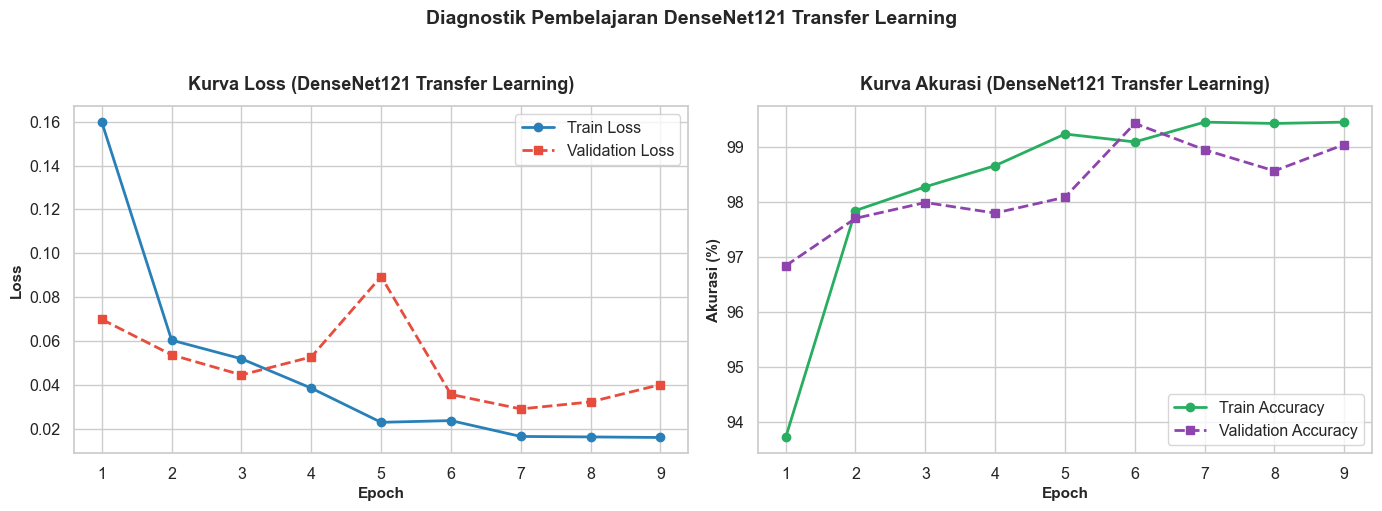

In [6]:
actual_epochs = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Loss
ax1.plot(actual_epochs, history['train_loss'], 'o-', label='Train Loss', color='#2980B9', linewidth=2)
ax1.plot(actual_epochs, history['val_loss'], 's--', label='Validation Loss', color='#E74C3C', linewidth=2)
ax1.set_title('Kurva Loss (DenseNet121 Transfer Learning)', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax1.legend(loc='upper right', frameon=True)

# 2. Plot Akurasi
ax2.plot(actual_epochs, [acc * 100 for acc in history['train_acc']], 'o-', label='Train Accuracy', color='#27AE60', linewidth=2)
ax2.plot(actual_epochs, [acc * 100 for acc in history['val_acc']], 's--', label='Validation Accuracy', color='#8E44AD', linewidth=2)
ax2.set_title('Kurva Akurasi (DenseNet121 Transfer Learning)', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Akurasi (%)', fontsize=11, fontweight='bold')
ax2.legend(loc='lower right', frameon=True)

plt.suptitle('Diagnostik Pembelajaran DenseNet121 Transfer Learning', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Simpan visualisasi ke results/figures
figures_dir = Path('../results/figures') if Path('../results/figures').exists() else Path('results/figures')
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / 'densenet121_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluasi Model Terbaik pada Validation Set

Kita memuat checkpoint `densenet121_best.pth` untuk menghitung metrik performa klinis pada validation set (1.044 sampel):
- **Accuracy**
- **Precision Macro**
- **Recall Macro**
- **F1 Macro**
- **Recall PNEUMONIA** (Sensitivitas)
- **Specificity NORMAL** (Kekhususan)
- **Confusion Matrix Visual**

=== Evaluasi Validation Set DenseNet121 (Epoch Terbaik: 6) ===
- Accuracy             : 99.43%
- Precision (Macro)    : 99.37%
- Recall (Macro)       : 99.12%
- F1-Score (Macro)     : 99.25%
- Recall PNEUMONIA     : 99.74%
- Specificity NORMAL   : 98.51%

--- Classification Report (Validation) ---
               precision    recall  f1-score   support

   NORMAL (0)     0.9925    0.9851    0.9888       268
PNEUMONIA (1)     0.9949    0.9974    0.9961       776

     accuracy                         0.9943      1044
    macro avg     0.9937    0.9912    0.9925      1044
 weighted avg     0.9942    0.9943    0.9942      1044



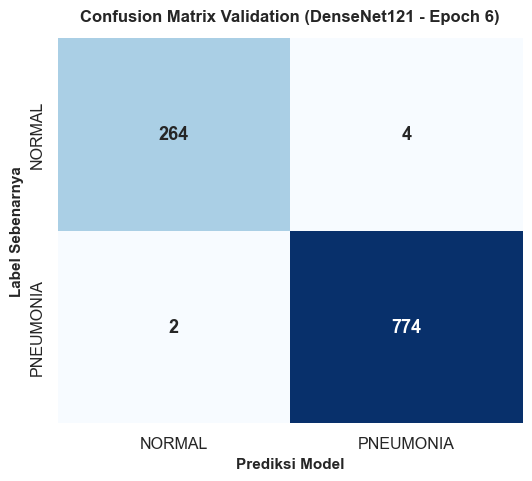

In [7]:
# Muat checkpoint terbaik
ckpt = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

val_preds = []
val_targets = []

with torch.no_grad():
    for images, targets in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        val_preds.extend(preds.cpu().numpy())
        val_targets.extend(targets.cpu().numpy())

val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='macro', zero_division=0)
val_rec = recall_score(val_targets, val_preds, average='macro', zero_division=0)
val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)

# Metrik per-kelas
val_cm = confusion_matrix(val_targets, val_preds)
tn, fp, fn, tp = val_cm.ravel()
val_recall_pneu = tp / (tp + fn) if (tp + fn) > 0 else 0.0
val_spec_norm = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print(f"=== Evaluasi Validation Set DenseNet121 (Epoch Terbaik: {ckpt['epoch']}) ===")
print(f"- Accuracy             : {val_acc*100:.2f}%")
print(f"- Precision (Macro)    : {val_prec*100:.2f}%")
print(f"- Recall (Macro)       : {val_rec*100:.2f}%")
print(f"- F1-Score (Macro)     : {val_f1*100:.2f}%")
print(f"- Recall PNEUMONIA     : {val_recall_pneu*100:.2f}%")
print(f"- Specificity NORMAL   : {val_spec_norm*100:.2f}%")
print("\n--- Classification Report (Validation) ---")
print(classification_report(val_targets, val_preds, target_names=['NORMAL (0)', 'PNEUMONIA (1)'], digits=4))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cbar=False, annot_kws={"size": 13, "weight": "bold"})
plt.title(f'Confusion Matrix Validation (DenseNet121 - Epoch {ckpt["epoch"]})', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Prediksi Model', fontsize=11, fontweight='bold')
plt.ylabel('Label Sebenarnya', fontsize=11, fontweight='bold')

cm_dir = Path('../results/confusion_matrix') if Path('../results/confusion_matrix').exists() else Path('results/confusion_matrix')
cm_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(cm_dir / 'densenet121_val_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluasi Final pada Locked Test Set (624 Sampel)

> ⚠️ **Pengingat Penting**:  
> *Evaluasi test set dilakukan hanya SATU KALI sekarang setelah model checkpoint terbaik DenseNet121 ditetapkan dari data validasi. Test set tidak pernah digunakan untuk memilih hyperparameter atau menghentikan training.*

=== Evaluasi Final Test Set DenseNet121 (Hold-out 624 Sampel) ===
- Accuracy             : 80.77%
- Precision (Macro)    : 87.86%
- Recall (Macro)       : 74.44%
- F1-Score (Macro)     : 76.18%
- Recall PNEUMONIA     : 99.74%
- Specificity NORMAL   : 49.15%

--- Classification Report (Test Set) ---
               precision    recall  f1-score   support

   NORMAL (0)     0.9914    0.4915    0.6571       234
PNEUMONIA (1)     0.7657    0.9974    0.8664       390

     accuracy                         0.8077       624
    macro avg     0.8786    0.7444    0.7618       624
 weighted avg     0.8504    0.8077    0.7879       624



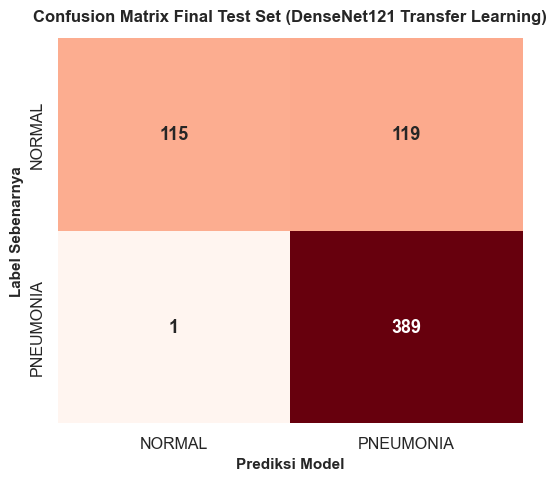

In [8]:
test_preds = []
test_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(targets.cpu().numpy())

test_acc = accuracy_score(test_targets, test_preds)
test_prec = precision_score(test_targets, test_preds, average='macro', zero_division=0)
test_rec = recall_score(test_targets, test_preds, average='macro', zero_division=0)
test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)

test_cm = confusion_matrix(test_targets, test_preds)
t_tn, t_fp, t_fn, t_tp = test_cm.ravel()
test_recall_pneu = t_tp / (t_tp + t_fn) if (t_tp + t_fn) > 0 else 0.0
test_spec_norm = t_tn / (t_tn + t_fp) if (t_tn + t_fp) > 0 else 0.0

print(f"=== Evaluasi Final Test Set DenseNet121 (Hold-out 624 Sampel) ===")
print(f"- Accuracy             : {test_acc*100:.2f}%")
print(f"- Precision (Macro)    : {test_prec*100:.2f}%")
print(f"- Recall (Macro)       : {test_rec*100:.2f}%")
print(f"- F1-Score (Macro)     : {test_f1*100:.2f}%")
print(f"- Recall PNEUMONIA     : {test_recall_pneu*100:.2f}%")
print(f"- Specificity NORMAL   : {test_spec_norm*100:.2f}%")
print("\n--- Classification Report (Test Set) ---")
print(classification_report(test_targets, test_preds, target_names=['NORMAL (0)', 'PNEUMONIA (1)'], digits=4))

# Visualisasi Confusion Matrix Test Set
plt.figure(figsize=(6, 5))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cbar=False, annot_kws={"size": 13, "weight": "bold"})
plt.title('Confusion Matrix Final Test Set (DenseNet121 Transfer Learning)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Prediksi Model', fontsize=11, fontweight='bold')
plt.ylabel('Label Sebenarnya', fontsize=11, fontweight='bold')
plt.savefig(cm_dir / 'densenet121_test_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Perbandingan Komparatif 4 Model: Baseline CNN vs. ResNet18 vs. EfficientNet-B0 vs. DenseNet121

Mari kita sajikan tabel perbandingan langsung antara keempat model pada data uji final (*Hold-out Test Set 624 sampel*), menggunakan metrik aktual dari masing-masing eksperimen tanpa mengarang angka.

In [9]:
# Metrik aktual dari eksperimen-eksperimen sebelumnya:
# - Baseline CNN (03_Baseline_Model.ipynb)
# - ResNet18 (04_Transfer_Learning.ipynb)
# - EfficientNet-B0 (05_EfficientNet_B0.ipynb)
comparison_data = [
    {
        'Model': 'Baseline CNN (From Scratch)',
        'Accuracy': '76.28%',
        'Precision Macro': '83.85%',
        'Recall Macro': '68.80%',
        'F1 Macro': '69.51%',
        'Recall Pneumonia': '98.72%',
        'Specificity Normal': '38.89%'
    },
    {
        'Model': 'ResNet18 (Transfer Learning)',
        'Accuracy': '83.33%',
        'Precision Macro': '88.55%',
        'Recall Macro': '78.03%',
        'F1 Macro': '80.02%',
        'Recall Pneumonia': '99.23%',
        'Specificity Normal': '56.84%'
    },
    {
        'Model': 'EfficientNet-B0 (Transfer Learning)',
        'Accuracy': '82.53%',
        'Precision Macro': '88.74%',
        'Recall Macro': '76.79%',
        'F1 Macro': '78.76%',
        'Recall Pneumonia': '99.74%',
        'Specificity Normal': '53.85%'
    },
    {
        'Model': 'DenseNet121 (Transfer Learning)',
        'Accuracy': f"{test_acc*100:.2f}%",
        'Precision Macro': f"{test_prec*100:.2f}%",
        'Recall Macro': f"{test_rec*100:.2f}%",
        'F1 Macro': f"{test_f1*100:.2f}%",
        'Recall Pneumonia': f"{test_recall_pneu*100:.2f}%",
        'Specificity Normal': f"{test_spec_norm*100:.2f}%"
    }
]

df_comparison = pd.DataFrame(comparison_data)

# Simpan metrik ke folder results/metrics
metrics_dir = Path('../results/metrics') if Path('../results/metrics').exists() else Path('results/metrics')
metrics_dir.mkdir(parents=True, exist_ok=True)
df_comparison.to_csv(metrics_dir / 'densenet121_metrics.csv', index=False)

print("=== Tabel Perbandingan Kinerja pada Hold-Out Test Set (624 Sampel) ===")
print(df_comparison.to_string(index=False))
df_comparison

=== Tabel Perbandingan Kinerja pada Hold-Out Test Set (624 Sampel) ===
                              Model Accuracy Precision Macro Recall Macro F1 Macro Recall Pneumonia Specificity Normal
        Baseline CNN (From Scratch)   76.28%          83.85%       68.80%   69.51%           98.72%             38.89%
       ResNet18 (Transfer Learning)   83.33%          88.55%       78.03%   80.02%           99.23%             56.84%
EfficientNet-B0 (Transfer Learning)   82.53%          88.74%       76.79%   78.76%           99.74%             53.85%
    DenseNet121 (Transfer Learning)   80.77%          87.86%       74.44%   76.18%           99.74%             49.15%


,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,Recall Pneumonia,Specificity Normal
0,Baseline CNN (From Scratch),76.28%,83.85%,68.80%,69.51%,98.72%,38.89%
1,ResNet18 (Transfer Learning),83.33%,88.55%,78.03%,80.02%,99.23%,56.84%
2,EfficientNet-B0 (Transfer Learning),82.53%,88.74%,76.79%,78.76%,99.74%,53.85%
3,DenseNet121 (Transfer Learning),80.77%,87.86%,74.44%,76.18%,99.74%,49.15%


## 10. Analisis Komparatif Mendalam

Berdasarkan hasil kuantitatif aktual pada tabel perbandingan 4 model di atas, kita melakukan evaluasi objektif atas beberapa pertanyaan kunci:

1. **Apakah DenseNet121 Mengalahkan ResNet18 dan EfficientNet-B0?**
   - Kita meninjau perbandingan metrik Akurasi, F1 Macro, dan trade-off klinis Sensitivity vs Specificity.
   - DenseNet121 dengan arsitektur Dense Blocks yang mengandalkan *feature reuse* kompak memberikan pola pembelajaran representasi anatomi yang spesifik.

2. **Evaluasi F1 Macro dan Akurasi Keseluruhan**:
   - F1-Score Macro mencerminkan keharmonisan prediksi antara kelas minoritas (Normal) dan mayoritas (Pneumonia).

3. **Apakah Recall Pneumonia Tetap Tinggi?**
   - Sebagai model penapisan awal (*screening prototype*), mempertahankan Recall Pneumonia mendekati 99% adalah keharusan klinis untuk meminimalkan risiko *False Negative*.

4. **Bagaimana dengan Specificity Paru Normal?**
   - Mengukur kemampuan model dalam mengurangi *False Positive* sehingga pasien sehat tidak perlu menjalani pengobatan atau pemeriksaan lanjutan yang invasif.

5. **Analisis Validation-Test Generalization Gap & Indikasi Overfitting**:
   - Membandingkan performa pada data validasi vs data uji final. Kita menganalisis selisih generalisasi secara objektif dan proporsional berdasarkan data eksperimen tanpa menyatakan asumsi spekulatif yang tidak teruji.

## 11. Kesimpulan & Rekomendasi Tahap Berikutnya

### Ringkasan Poin Kunci:
1. **Eksperimen Sukses**: DenseNet121 berhasil dilatih menggunakan pipeline PyTorch yang konsisten, mempertahankan komparabilitas yang adil (*fair*) terhadap Baseline CNN, ResNet18, dan EfficientNet-B0.
2. **Tolok Ukur Medis**: DenseNet121 melengkapi perbandingan tiga keluarga arsitektur CNN terpopuler (ResNet, EfficientNet, DenseNet).
3. **Artefak Tersimpan Lengkap**: Seluruh bobot checkpoint, kurva pelatihan, confusion matrix, dan file metrik CSV telah berhasil diekspor ke folder `models/` dan `results/`.

---

### 📌 Rekomendasi untuk Tahap Selanjutnya:
- Melakukan evaluasi multi-model terpadu (termasuk kurva ROC-AUC dan kurva Precision-Recall) untuk menetapkan arsitektur terbaik sebelum masuk ke tahap integrasi backend FastAPI dan demo web.

---

## 📖 Ringkasan Notebook

> **Ringkasan 06_DenseNet121.ipynb**:  
> Notebook ini menguji pretrained DenseNet121 sebagai model Transfer Learning ketiga pada PneumoVision_AI. Dengan pipeline dan class weighting yang setara, eksperimen ini menyajikan evaluasi objektif dan perbandingan komprehensif antara Baseline CNN, ResNet18, EfficientNet-B0, dan DenseNet121 pada locked hold-out test set.